In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import polars as pl 
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [3]:
df = pl.read_csv("../data/electricity_cost_dataset.csv")
print(df.head())

shape: (5, 9)
┌──────┬────────────┬────────────┬────────────┬───┬────────────┬───────────┬───────────┬───────────┐
│ site ┆ structure  ┆ water cons ┆ recycling  ┆ … ┆ air        ┆ issue res ┆ resident  ┆ electrici │
│ area ┆ type       ┆ umption    ┆ rate       ┆   ┆ quality    ┆ olution   ┆ count     ┆ ty cost   │
│ ---  ┆ ---        ┆ ---        ┆ ---        ┆   ┆ index      ┆ time      ┆ ---       ┆ ---       │
│ i64  ┆ str        ┆ f64        ┆ i64        ┆   ┆ ---        ┆ ---       ┆ i64       ┆ f64       │
│      ┆            ┆            ┆            ┆   ┆ i64        ┆ i64       ┆           ┆           │
╞══════╪════════════╪════════════╪════════════╪═══╪════════════╪═══════════╪═══════════╪═══════════╡
│ 1360 ┆ Mixed-use  ┆ 2519.0     ┆ 69         ┆ … ┆ 188        ┆ 1         ┆ 72        ┆ 1420.0    │
│ 4272 ┆ Mixed-use  ┆ 2324.0     ┆ 50         ┆ … ┆ 165        ┆ 65        ┆ 261       ┆ 3298.0    │
│ 3592 ┆ Mixed-use  ┆ 2701.0     ┆ 20         ┆ … ┆ 198        ┆ 39        ┆ 

In [4]:
X = df[['site area', 'water consumption', 'recycling rate', 
        'utilisation rate', 'air quality index', 
        'issue resolution time', 'resident count']]

In [19]:
X_const = add_constant(X)

In [21]:
print(type(X_const))
print(type(X))

<class 'numpy.ndarray'>
<class 'polars.dataframe.frame.DataFrame'>


In [22]:
feature_names = ['const'] + list(X.columns)

vif_data = pd.DataFrame({
    "feature": feature_names,
    "VIF": [variance_inflation_factor(np.asarray(X_const), i) 
            for i in range(np.asarray(X_const).shape[1])]
})

vif_data = vif_data[vif_data["feature"] != "const"]
print(vif_data.sort_values("VIF", ascending=False))

                 feature       VIF
1              site area  2.383160
2      water consumption  2.251372
7         resident count  1.150414
5      air quality index  1.001236
6  issue resolution time  1.001186
4       utilisation rate  1.001086
3         recycling rate  1.000859


In [23]:
df.schema

Schema([('site area', Int64),
        ('structure type', String),
        ('water consumption', Float64),
        ('recycling rate', Int64),
        ('utilisation rate', Int64),
        ('air quality index', Int64),
        ('issue resolution time', Int64),
        ('resident count', Int64),
        ('electricity cost', Float64)])

In [24]:
df.shape, df['structure type'].n_unique()

((10000, 9), 4)

In [25]:
# missing values

missing_values = df.null_count()
print(f"Total missing values: {missing_values.to_numpy().sum()}")

Total missing values: 0


In [26]:
df.describe()

statistic,site area,structure type,water consumption,recycling rate,utilisation rate,air quality index,issue resolution time,resident count,electricity cost
str,f64,str,f64,f64,f64,f64,f64,f64,f64
"""count""",10000.0,"""10000""",10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
"""null_count""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",2757.7751,null,3494.0571,49.598,64.8422,99.4686,36.4026,85.5731,2837.845
"""std""",1293.059959,null,2076.181117,23.430141,20.432965,58.014526,20.623905,107.876179,1106.997441
"""min""",501.0,"""Commercial""",1000.0,10.0,30.0,0.0,1.0,0.0,500.0
"""25%""",1624.0,null,1779.0,30.0,47.0,49.0,19.0,0.0,1954.0
"""50%""",2774.0,null,3048.0,49.0,65.0,100.0,36.0,39.0,2760.0
"""75%""",3874.0,null,4811.0,70.0,83.0,150.0,54.0,142.0,3632.0
"""max""",5000.0,"""Residential""",10894.0,90.0,100.0,200.0,72.0,489.0,6446.0


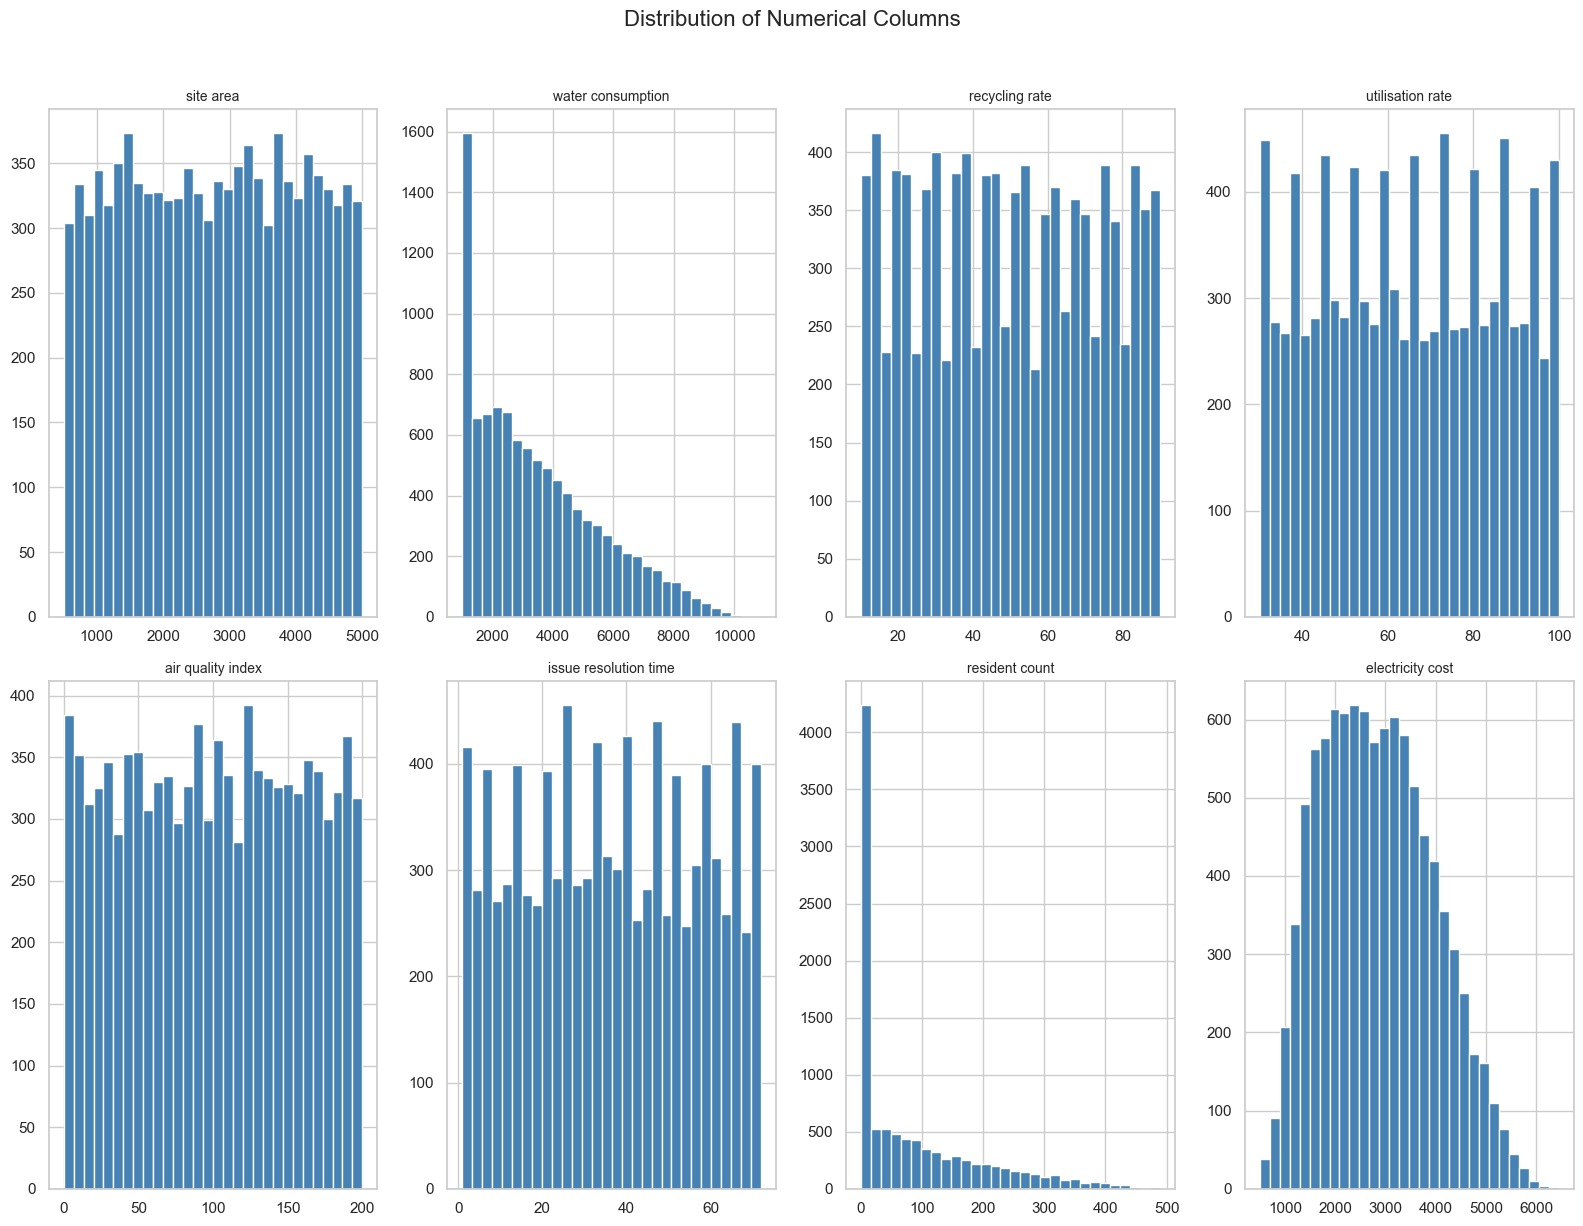

In [27]:
num_cols = [col for col, dtype in df.schema.items() if dtype in [pl.Float64, pl.Int64]]

fig, axes = plt.subplots(2, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].to_numpy(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerical Columns', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

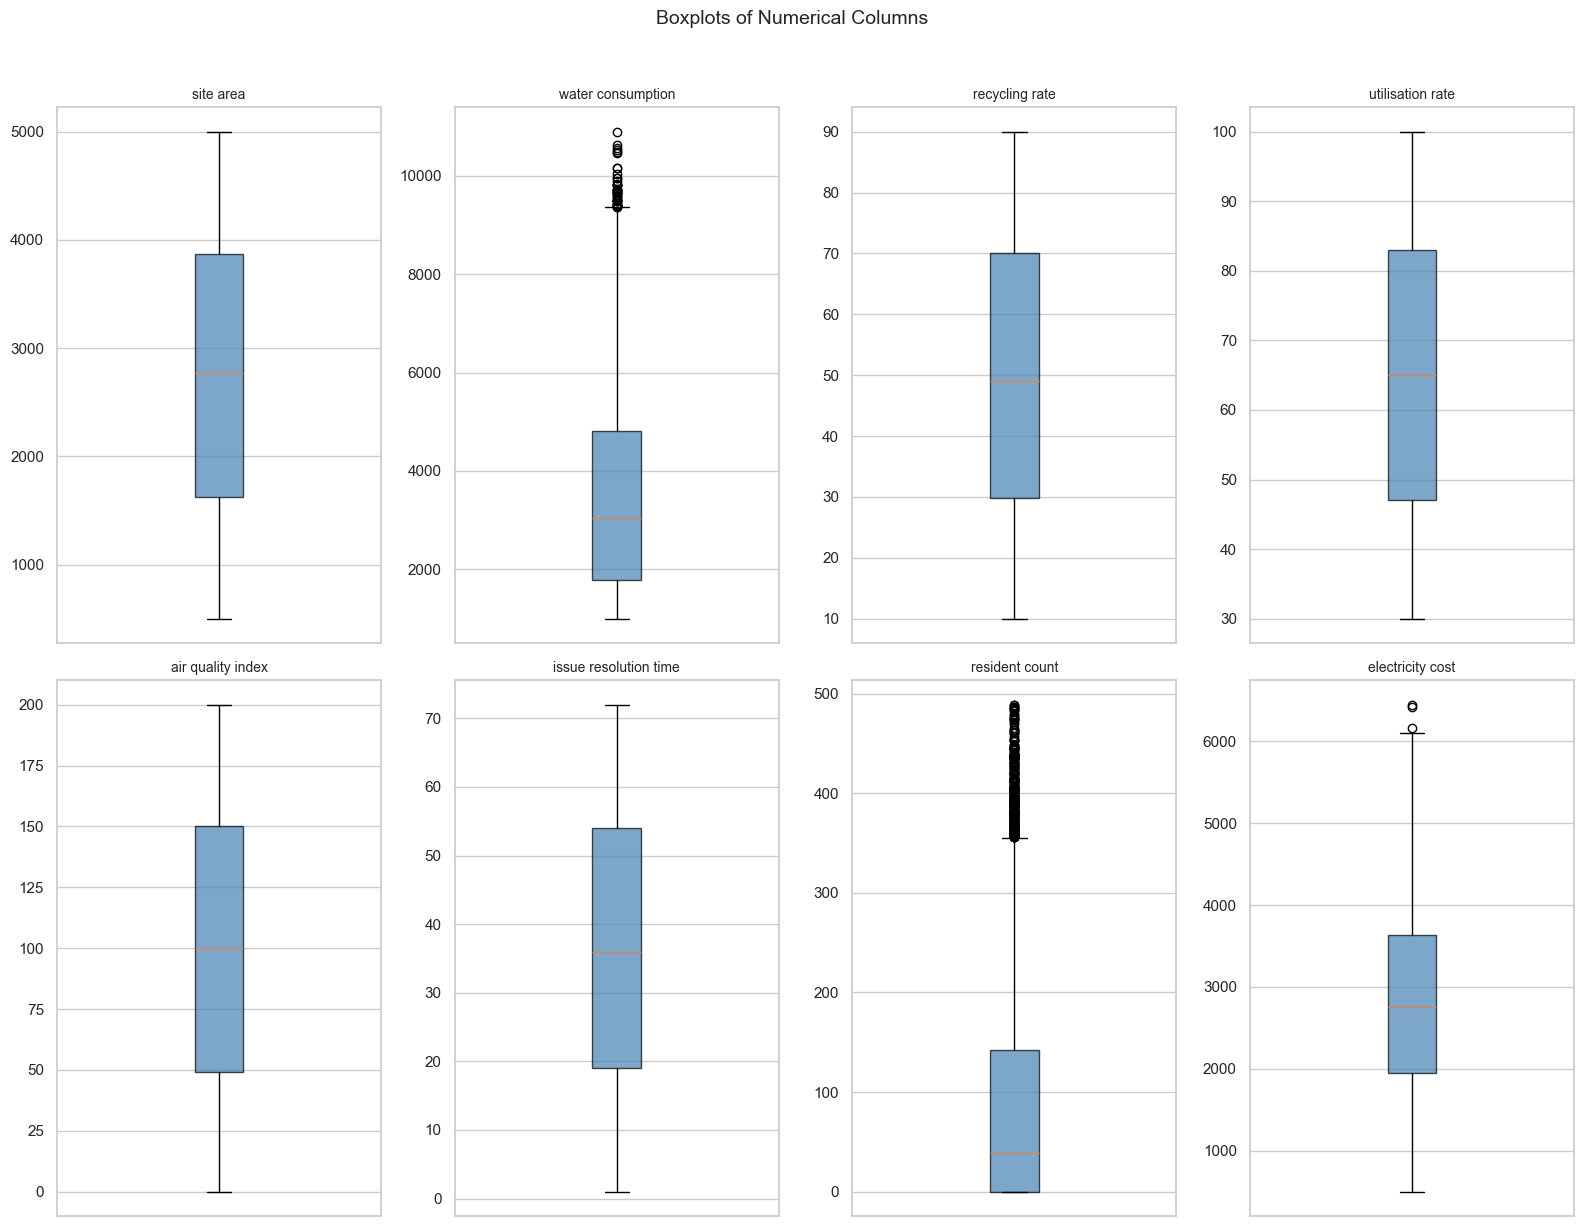

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].to_numpy(), patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticks([])

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots of Numerical Columns', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [29]:
# Outlier Detection with IQR Method

for  col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr 
    lower = q1 - 1.5 * iqr
    outliers = df.filter((pl.col(col) > upper) | (pl.col(col) < lower)).shape[0]
    if outliers > 0:
        print(f"Column '{col}': {outliers} outliers ({(outliers / df.shape[0]) * 100:.1f}%)") 

Column 'water consumption': 43 outliers (0.4%)
Column 'resident count': 289 outliers (2.9%)
Column 'electricity cost': 3 outliers (0.0%)


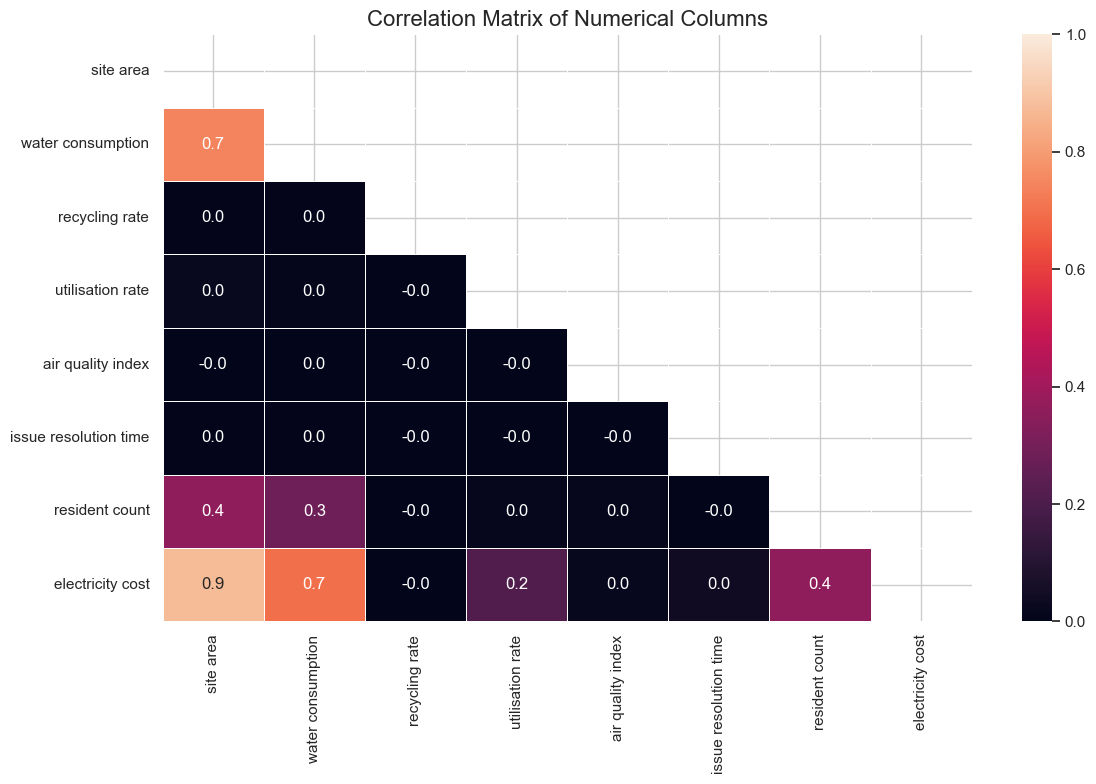

In [30]:
corr_matrix = np.corrcoef(df.select(num_cols).to_numpy().T)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.1f', linewidths=0.5, vmin=0, vmax=1, xticklabels=num_cols, yticklabels=num_cols)
plt.title('Correlation Matrix of Numerical Columns', fontsize=16)
plt.tight_layout()
plt.show()

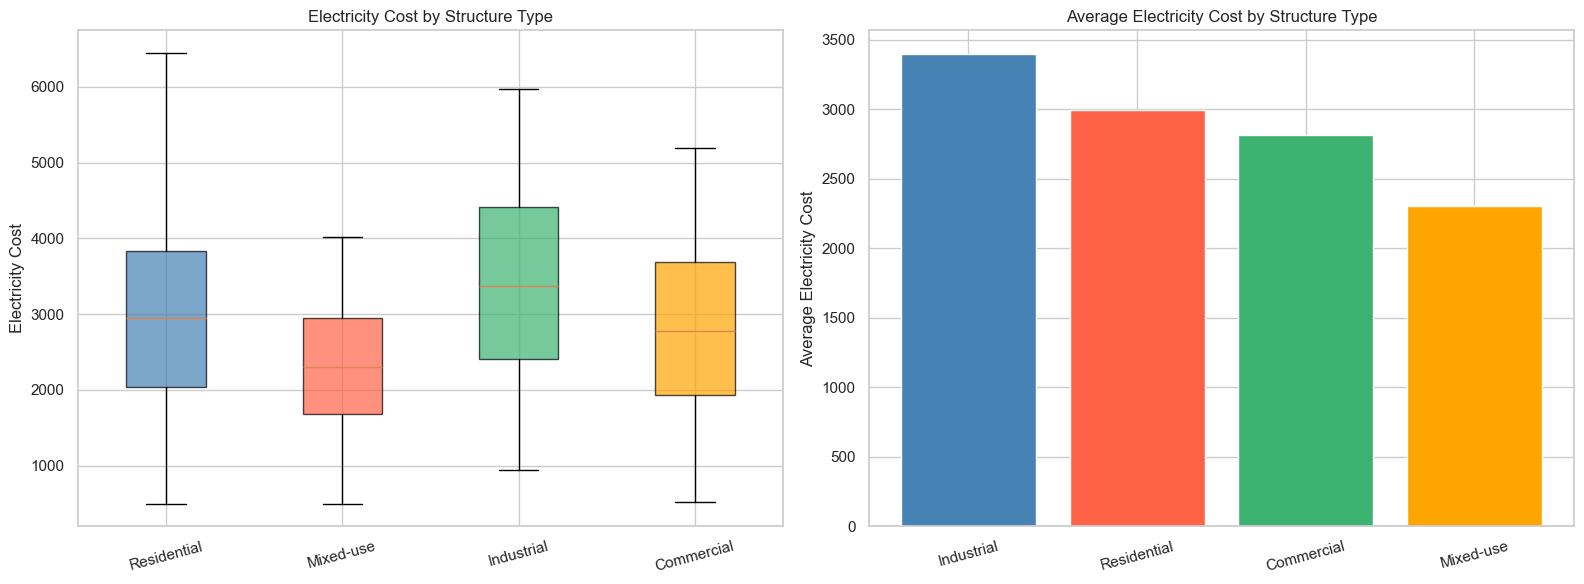

In [31]:
structures_df = df['structure type'].unique().to_list()
colors = ['steelblue', 'tomato', 'mediumseagreen', 'orange']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

data_by_type = [df.filter(pl.col('structure type') == t)['electricity cost'].to_numpy()
                 for t in structures_df]
bp = axes[0].boxplot(data_by_type, patch_artist=True, flierprops=dict(marker='o', markersize=3))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_xticklabels(structures_df, rotation=15)
axes[0].set_title('Electricity Cost by Structure Type')
axes[0].set_ylabel('Electricity Cost')

# mean values
avg_by_type = (
    df.group_by('structure type')
    .agg(pl.col('electricity cost').mean().alias('mean cost'))
    .sort('mean cost', descending=True)
)

axes[1].bar(avg_by_type['structure type'].to_list(),
            avg_by_type['mean cost'].to_list(),
            color=colors, edgecolor='white')
axes[1].set_title('Average Electricity Cost by Structure Type')
axes[1].tick_params(axis='x', rotation=15)
axes[1].set_ylabel('Average Electricity Cost')

plt.tight_layout()
plt.show()

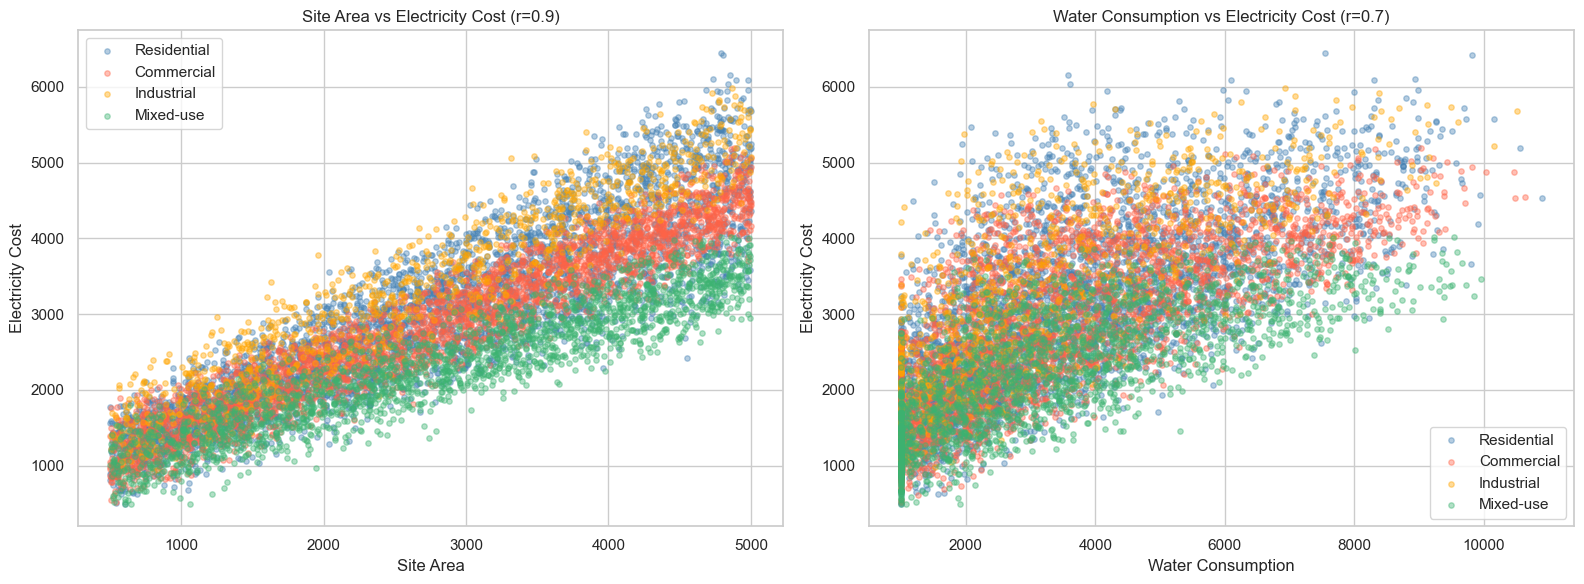

In [32]:
# site area - max corr with target feature

fig, axes = plt.subplots(1, 2, figsize=(16, 6)) 

color_map = {'Residential': 'steelblue', 'Commercial': 'tomato', 'Industrial': 'orange', 'Mixed-use': 'mediumseagreen'}
for stype, color in color_map.items():
    subset = df.filter(pl.col('structure type') == stype)
    axes[0].scatter(subset['site area'].to_numpy(),
                    subset['electricity cost'].to_numpy(),
                    label=stype, color=color, alpha=0.4, s=15)

axes[0].set_xlabel('Site Area')
axes[0].set_ylabel('Electricity Cost')
axes[0].set_title('Site Area vs Electricity Cost (r=0.9)')
axes[0].legend()

# water consumption vs electricity cost

for stype, color in color_map.items():
    subset = df.filter(pl.col('structure type') == stype)
    axes[1].scatter(subset['water consumption'].to_numpy(),
                    subset['electricity cost'].to_numpy(),
                    label=stype, color=color, alpha=0.4, s=15)
    
axes[1].set_xlabel('Water Consumption')
axes[1].set_ylabel('Electricity Cost')
axes[1].set_title('Water Consumption vs Electricity Cost (r=0.7)')
axes[1].legend()

plt.tight_layout()
plt.show()